# 02 — Modelos tabulares: triaje y sospecha de enfermedad

Este notebook explica el servicio `ml-triage`, sus modelos tabulares, artefactos, métricas, matrices de confusión y análisis crítico.

ROOT = c:\Users\aripa\Downloads\Practica_Hospital_BACKUP_20260516_145943


# 02 — ML Triage tabular

Este notebook explica el módulo `services/ml-triage`, responsable de aplicar modelos tabulares sobre fichas clínicas.

El servicio tiene dos responsabilidades principales:

1. **Modelo de triaje**: clasifica el nivel de urgencia del paciente en `Alta`, `Media` o `Baja`.
2. **Modelo de sospecha de enfermedad**: estima una sospecha orientativa a partir de los síntomas auto-reportados.

Este módulo se integra con el pipeline y el dashboard.

```text
Formulario / CSV batch
        |
        v
pipeline
        |
        v
ml-triage /predict
        |
        v
predicción de triaje + sospecha de enfermedad
        |
        v
MongoDB + API + Dashboard
```

El objetivo no es sustituir al médico, sino aportar **apoyo a la decisión clínica**.

## 1. Estructura de `services/ml-triage`

El módulo se divide en dos partes:

| Carpeta | Función |
|---|---|
| `app/` | Servicio FastAPI de inferencia tabular. Carga modelos y expone `/predict`. |
| `training/` | Código offline para generar dataset sintético, entrenar, evaluar y analizar críticamente los modelos. |

Separación importante:

- `training/` entrena y genera artefactos.
- `app/` carga artefactos ya entrenados y sirve predicciones.

...

#### Matriz de confusión numérica

,Pred: Alta,Pred: Media,Pred: Baja
Real: Alta,223,48,7
Real: Media,18,911,13
Real: Baja,1,36,243


#### Errores principales fuera de la diagonal

,clase_real,clase_predicha,casos
0,Alta,Media,48
5,Baja,Media,36
2,Media,Alta,18
3,Media,Baja,13
1,Alta,Baja,7
4,Baja,Alta,1


#### Matriz de confusión visual

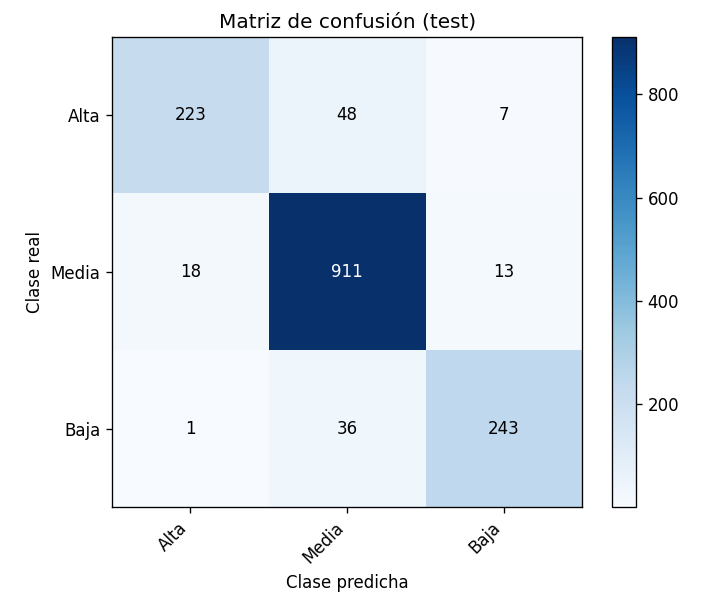

#### Análisis crítico generado

# Análisis crítico — modelo de triaje `tri-20260514-60eff3c2`

**Fecha de evaluación**: 2026-05-14T15:32:01.775256+00:00

## 1. Resumen de rendimiento

- **Accuracy**: 0.9180
- **F1 macro**: 0.8978
- **Recall clase Alta**: 0.8022 *(métrica clínicamente crítica — falsos negativos de Alta son el peor escenario)*

## 2. Error más frecuente

El error más frecuente en la matriz de confusión es **Alta → Media** con **48 casos** sobre 1500 registros de test.

**Impacto clínico**: Un paciente urgente fue clasificado como moderado. Retraso potencial en su atención, con riesgo clínico si se trata de patología tiempo-dependiente.

## 3. Comportamiento ante la variable espuria

`hora_envio` es una variable espuria (ver DESIGN-08 §4.3): se genera aleatoriamente en el dataset sintético y **no** está presente en ninguna regla clínica. Un modelo bien entrenado debería asignarle importancia **muy baja**.

- Importancia normalizada de `hora_envio`: **0.0095** (ratio respecto a la feature más importante).

> ⚠️ **Aviso**: `hora_envio` tiene importancia superior al umbral (0.0050). Esto sugiere que el generador sintético ha introducido alguna correlación accidental con el target. Revisar `generate_dataset.py` antes de defender resultados.

## 4. Top 5 features por importancia (permutation)

| # | Feature | Importancia (permutation) |
|---|---------|---------------------------|
| 1 | `dificultad_respiratoria_subjetiva` | 0.1749 |
| 2 | `edad` | 0.1619 |
| 3 | `fiebre_subjetiva` | 0.1371 |
| 4 | `motivo_principal` | 0.0942 |
| 5 | `intensidad_dolor` | 0.0903 |

## 5. Limitación fundamental

El dataset es **sintético** y sus etiquetas vienen de reglas que el propio equipo ha codificado, más un **10 % de ruido** deliberado (ver DESIGN-08 §4.4, §4.5). El modelo, por construcción, reproduce esas reglas; sus métricas **no reflejan utilidad clínica real**.

Su valor es **pedagógico**: demuestra que el flujo SDD → dataset → entrenamiento → evaluación → servicio HTTP funciona end-to-end, con trazabilidad, reproducibilidad y análisis crítico alineados con el enunciado §3.1 y §7.

En un despliegue clínico real, este modelo **no sustituye** al juicio del personal sanitario ni constituye un dispositivo médico validado.


---

### Modelo `dis-20260514-8c9a3874`

**Familia:** `disease`

,métrica,valor
0,accuracy,0.926667
1,f1_macro,0.866529
2,f1_weighted,0.925010


#### Métricas por clase

...

#### Matriz de confusión numérica

,Pred: apendicitis_sospecha,Pred: asma_epoc_exacerbacion,Pred: cardiopatia_aguda_sospecha,Pred: cefalea_migrana,Pred: covid_sospecha,Pred: gastroenteritis,Pred: gripe_resfriado,Pred: ictus_sospecha,Pred: inespecifico,Pred: neumonia_sospecha,Pred: traumatismo
Real: apendicitis_sospecha,291,2,5,0,0,0,0,0,0,0,8
Real: asma_epoc_exacerbacion,13,12,2,1,0,0,0,0,0,0,2
Real: cardiopatia_aguda_sospecha,9,0,127,0,0,0,1,0,0,0,3
Real: cefalea_migrana,0,0,0,10,0,0,0,0,0,0,3
Real: covid_sospecha,0,0,0,0,88,0,0,0,0,0,2
Real: gastroenteritis,0,0,0,0,0,177,11,0,0,0,2
Real: gripe_resfriado,0,0,0,0,0,3,22,0,0,0,1
Real: ictus_sospecha,0,0,0,0,0,0,0,199,0,0,2
Real: inespecifico,0,0,0,0,0,0,0,0,36,4,2
Real: neumonia_sospecha,0,0,0,0,0,0,0,0,3,42,2


#### Errores principales fuera de la diagonal

,clase_real,clase_predicha,casos
10,asma_epoc_exacerbacion,apendicitis_sospecha,13
55,gastroenteritis,gripe_resfriado,11
105,traumatismo,gastroenteritis,10
107,traumatismo,ictus_sospecha,10
20,cardiopatia_aguda_sospecha,apendicitis_sospecha,9
9,apendicitis_sospecha,traumatismo,8
104,traumatismo,covid_sospecha,5
1,apendicitis_sospecha,cardiopatia_aguda_sospecha,5
88,inespecifico,neumonia_sospecha,4
65,gripe_resfriado,gastroenteritis,3


#### Matriz de confusión visual

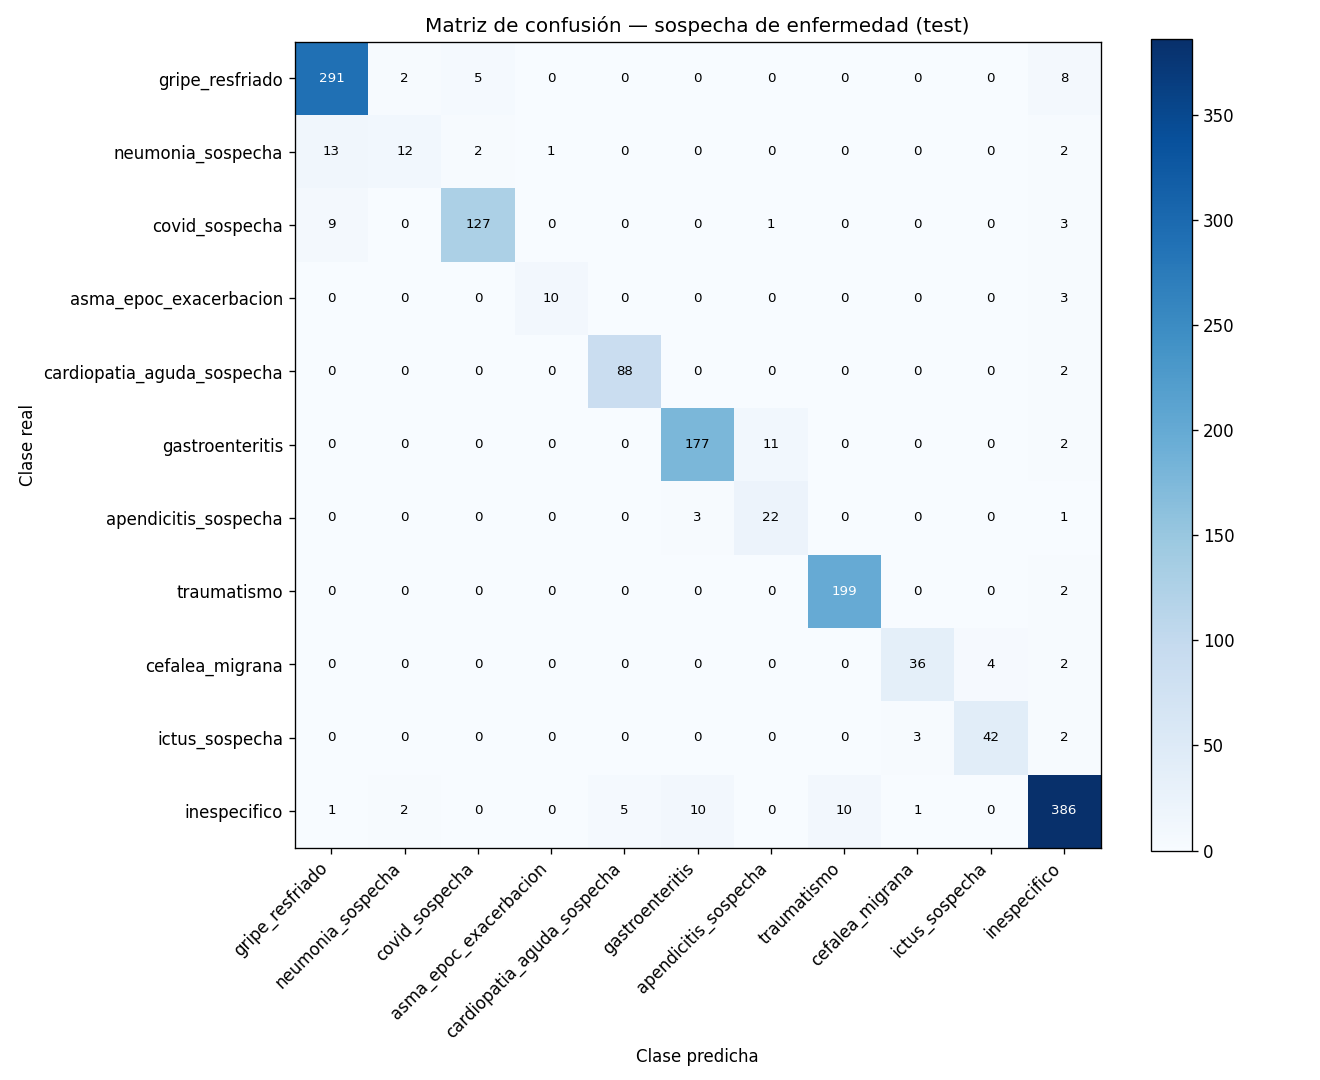

#### Análisis crítico generado

# Análisis crítico — modelo de enfermedad `dis-20260514-8c9a3874`

**Fecha de evaluación**: 2026-05-14T15:32:16.381565+00:00

## 1. Resumen de rendimiento

- **Accuracy**: 0.9267
- **F1 macro**: 0.8665 *(media simple — sensible al desbalance de clases minoritarias)*
- **F1 weighted**: 0.9250 *(ponderada por soporte — más representativa del rendimiento global)*

## 2. Top 5 errores más frecuentes

| # | Real | Predicha | Casos |
|---|------|----------|-------|
| 1 | Sospecha de neumonía | Gripe / resfriado | 13 |
| 2 | Gastroenteritis | Sospecha de apendicitis | 11 |
| 3 | Cuadro inespecífico | Gastroenteritis | 10 |
| 4 | Cuadro inespecífico | Traumatismo | 10 |
| 5 | Sospecha de COVID-19 | Gripe / resfriado | 9 |

Los errores entre clases **clínicamente próximas** (gripe ↔ COVID, gastroenteritis ↔ apendicitis, cefalea ↔ ictus) son esperables — reflejan la matriz de proximidad clínica del ruido tipo A (DESIGN-08b §4.4). Los errores entre clases lejanas (p. ej. traumatismo → cardiopatia) son señal de problema y requieren revisión del generador o del entrenamiento.

## 3. F1 por clase (peor → mejor)

| Clase | F1 | Precisión | Recall | Soporte |
|-------|----|-----------|--------|---------|
| Sospecha de neumonía | 0.522 | 0.750 | 0.400 | 30 |
| Sospecha de apendicitis | 0.733 | 0.647 | 0.846 | 26 |
| Exacerbación asma/EPOC | 0.833 | 0.909 | 0.769 | 13 |
| Cefalea / migraña | 0.878 | 0.900 | 0.857 | 42 |
| Sospecha de ictus | 0.903 | 0.913 | 0.894 | 47 |
| Sospecha de COVID-19 | 0.927 | 0.948 | 0.907 | 140 |
| Gastroenteritis | 0.932 | 0.932 | 0.932 | 190 |
| Cuadro inespecífico | 0.932 | 0.935 | 0.930 | 415 |
| Gripe / resfriado | 0.939 | 0.927 | 0.951 | 306 |
| Sospecha cardiopatía aguda | 0.962 | 0.946 | 0.978 | 90 |
| Traumatismo | 0.971 | 0.952 | 0.990 | 201 |

Las clases minoritarias clínicas (neumonía, asma/EPOC, apendicitis) tienen soporte bajo — el F1 es ruidoso. `class_weight='balanced'` compensa parcialmente: trade-off entre recall en minoritarias (falsos positivos) vs precision en mayoritarias.

## 4. Comportamiento ante la variable espuria

`hora_envio` es una variable espuria (DESIGN-08 §4.3): se genera aleatoriamente y **no** aparece en ninguna regla del generador. Un modelo bien entrenado debe asignarle importancia muy baja.

- Importancia normalizada de `hora_envio`: **-0.0014** (ratio respecto a la feature más importante).

## 5. Top 5 features por importancia (permutation)

| # | Feature | Importancia |
|---|---------|-------------|
| 1 | `motivo_principal` | 0.6547 |
| 2 | `contacto_covid_reciente` | 0.1408 |
| 3 | `fiebre_subjetiva` | 0.0788 |
| 4 | `tos` | 0.0781 |
| 5 | `edad` | 0.0445 |

## 6. Limitación crítica (obligatoria)

Las etiquetas de enfermedad son **sintéticas**, generadas por reglas heurísticas que el equipo ha codificado a mano. El modelo aprende esas reglas con un 10 % de ruido — **no aprende patrones epidemiológicos reales**. Su uso clínico real está **explícitamente desautorizado**: la salida es una sospecha orientativa para apoyo administrativo (priorización de admisión), nunca un diagnóstico.

En un sistema real haría falta entrenamiento con historiales clínicos validados, supervisión médica continua, y certificación regulatoria (CE, FDA, AEMPS). El valor de este modelo es **pedagógico**: demuestra el flujo SDD → reglas → dataset → entrenamiento → evaluación → servicio HTTP con un segundo target sobre el mismo formulario, alineado con §3.1 ("predicción de enfermedades") y §7 (ética y limitaciones) del enunciado.

## 7. Desbalance de clases — discusión

La distribución de `disease_target` es naturalmente desbalanceada: `asma_epoc_exacerbacion` ~0.8 %, `neumonia_sospecha` ~1.5 % vs `inespecifico` ~30 % o `gripe_resfriado` ~20 %. Esto refleja frecuencias plausibles en un servicio de admisión real, no un defecto del generador (DESIGN-08b §4.3). Compensamos con `class_weight='balanced'` en el entrenamiento — alternativas consideradas y descartadas: oversampling SMOTE (introduce muestras sintéticas no clínicas), inflar artificialmente las features de entrada (rompe el realismo de la generación).


## 8. Configuración activa del servicio

El servicio `ml-triage` carga los modelos activos desde los punteros `current.txt`.

,familia,current.txt,ruta
0,triage,tri-20260514-60eff3c2,models\triage\current.txt
1,disease,dis-20260514-8c9a3874,models\disease\current.txt


## 9. Pruebas opcionales contra `/predict`

Esta sección puede llamar al servicio real `ml-triage`.

Por defecto está desactivada. Cambia `RUN_API_CHECKS = True` si tienes Docker Compose levantado.

...

### Comprobar servicio levantado

```powershell
docker compose ps ml-triage
docker compose logs ml-triage --tail=50
```

### Probar healthcheck

```powershell
curl.exe -s http://localhost:8002/healthz
curl.exe -s http://localhost:8002/health
```

## 11. Resumen para defensa

El módulo `ml-triage` demuestra la parte de Machine Learning tabular del proyecto:

1. Usa fichas clínicas estructuradas.
2. Convierte síntomas auto-reportados en variables del modelo.
3. Entrena un modelo de triaje (`Alta`, `Media`, `Baja`).
4. Entrena un modelo de sospecha de enfermedad.
5. Genera métricas, matrices de confusión y análisis crítico.
6. Expone inferencia mediante FastAPI.
7. Se integra con el pipeline batch y online.
8. Guarda resultados en MongoDB para API y dashboard.
9. Mantiene separación entre entrenamiento offline e inferencia online.
10. No sustituye criterio médico: actúa como apoyo a la decisión.

Punto clave para la defensa:

> El modelo de triaje prioriza pacientes según síntomas y factores de riesgo. El error más crítico no es fallar una etiqueta cualquiera, sino infratriar un caso grave, por ejemplo clasificar como `Baja` un paciente que debería ser `Alta`. Por eso se analizan matrices de confusión y critical analysis, no solo accuracy.

In [3]:
from pathlib import Path
import ast
import json
import subprocess
import textwrap

import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown, Image as IPImage


# =============================================================================
# 0. Utilidades base
# =============================================================================

FENCE = "`" * 3


def md(text: str) -> None:
    """Renderiza Markdown desde una celda Python."""
    display(Markdown(textwrap.dedent(text).strip()))


def code_block(lang: str, text: str) -> None:
    """Renderiza bloques de código sin romper la celda Python."""
    display(Markdown(f"{FENCE}{lang}\n{textwrap.dedent(text).strip()}\n{FENCE}"))


def find_project_root(start: Path | None = None) -> Path:
    """Busca la raíz del proyecto localizando docker-compose.yml."""
    start = Path.cwd() if start is None else Path(start)

    for candidate in [start, *start.parents]:
        if (candidate / "docker-compose.yml").exists():
            return candidate

    return start


ROOT = find_project_root()
print(f"ROOT = {ROOT}")


def read_json(path: Path, default=None):
    """Lee JSON de forma segura."""
    path = Path(path)

    if not path.exists():
        return default

    try:
        return json.loads(path.read_text(encoding="utf-8"))
    except Exception as exc:
        print(f"[error leyendo JSON] {path}: {exc}")
        return default


def read_text(path: Path, default: str = "") -> str:
    """Lee texto de forma segura."""
    path = Path(path)

    if not path.exists():
        return default

    try:
        return path.read_text(encoding="utf-8", errors="ignore")
    except Exception:
        return default


def read_env(path: Path) -> dict:
    """Lee variables simples desde .env."""
    env = {}
    path = Path(path)

    if not path.exists():
        return env

    for raw in path.read_text(encoding="utf-8", errors="ignore").splitlines():
        line = raw.strip()

        if not line or line.startswith("#") or "=" not in line:
            continue

        key, value = line.split("=", 1)
        env[key.strip()] = value.strip().strip('"').strip("'")

    return env


def run_cmd(cmd: str, timeout: int = 60) -> str:
    """Ejecuta un comando shell y devuelve stdout/stderr."""
    print(f"$ {cmd}")

    try:
        result = subprocess.run(
            cmd,
            shell=True,
            cwd=ROOT,
            text=True,
            capture_output=True,
            timeout=timeout,
        )

        if result.stdout:
            print(result.stdout)

        if result.stderr:
            print(result.stderr)

        print(f"exit_code={result.returncode}")
        return (result.stdout or "") + (result.stderr or "")

    except Exception as exc:
        print(f"[error] {exc}")
        return str(exc)


def file_size_mb(path: Path) -> float | None:
    try:
        return round(path.stat().st_size / (1024 * 1024), 3)
    except Exception:
        return None


def file_size_kb(path: Path) -> float | None:
    try:
        return round(path.stat().st_size / 1024, 2)
    except Exception:
        return None


def line_count(path: Path) -> int | None:
    try:
        return len(path.read_text(encoding="utf-8", errors="ignore").splitlines())
    except Exception:
        return None


def extract_docstring(path: Path) -> str:
    """Extrae docstring principal de un .py."""
    try:
        source = path.read_text(encoding="utf-8", errors="ignore")
        tree = ast.parse(source)
        doc = ast.get_docstring(tree) or ""
        return " ".join(doc.strip().split())
    except Exception:
        return ""


def extract_public_symbols(path: Path) -> list[str]:
    """Lista clases y funciones públicas de un .py."""
    try:
        source = path.read_text(encoding="utf-8", errors="ignore")
        tree = ast.parse(source)

        functions = []
        classes = []

        for node in ast.walk(tree):
            if isinstance(node, (ast.FunctionDef, ast.AsyncFunctionDef)) and not node.name.startswith("_"):
                functions.append(node.name)

            if isinstance(node, ast.ClassDef) and not node.name.startswith("_"):
                classes.append(node.name)

        out = [f"class {name}" for name in sorted(set(classes))]
        out += [f"def {name}" for name in sorted(set(functions))]
        return out

    except Exception:
        return []


def normalize_confusion_matrix(raw_cm, labels: list[str]) -> tuple[list[list[int]] | None, list[str]]:
    """
    Convierte confusion_matrix a lista de listas.
    Soporta lista de listas, dict de dicts, dict con key interna y lista de dicts.
    """
    if raw_cm is None:
        return None, labels

    if isinstance(raw_cm, dict):
        for inner_key in ["matrix", "values", "data", "confusion_matrix"]:
            if inner_key in raw_cm:
                return normalize_confusion_matrix(raw_cm[inner_key], labels)

        row_labels = list(raw_cm.keys())

        if all(isinstance(v, dict) for v in raw_cm.values()):
            col_labels = labels if labels and len(labels) == len(row_labels) else row_labels
            matrix = [
                [int(raw_cm.get(row_label, {}).get(col_label, 0)) for col_label in col_labels]
                for row_label in row_labels
            ]
            labels = row_labels if len(row_labels) == len(matrix) else col_labels
            return matrix, labels

        if all(isinstance(v, (list, tuple)) for v in raw_cm.values()):
            matrix = [list(map(int, row)) for row in raw_cm.values()]
            labels = row_labels if len(row_labels) == len(matrix) else labels
            return matrix, labels

        return None, labels

    if isinstance(raw_cm, list) and raw_cm and all(isinstance(row, dict) for row in raw_cm):
        col_labels = labels if labels and len(labels) == len(raw_cm) else list(raw_cm[0].keys())
        matrix = [
            [int(row.get(col_label, 0)) for col_label in col_labels]
            for row in raw_cm
        ]
        labels = col_labels if len(col_labels) == len(matrix) else [f"Clase {i}" for i in range(len(matrix))]
        return matrix, labels

    if isinstance(raw_cm, list):
        matrix = []

        for row in raw_cm:
            if isinstance(row, (list, tuple)):
                matrix.append([int(x) for x in row])
            else:
                return None, labels

        if not labels or len(labels) != len(matrix):
            labels = [f"Clase {i}" for i in range(len(matrix))]

        return matrix, labels

    return None, labels


ml_root = ROOT / "services" / "ml-triage"
triage_models_root = ROOT / "models" / "triage"
disease_models_root = ROOT / "models" / "disease"


# =============================================================================
# 1. Introducción
# =============================================================================

md("""
# 02 — ML Triage tabular

Este notebook explica el módulo `services/ml-triage`, responsable de aplicar modelos tabulares sobre fichas clínicas.

El servicio tiene dos responsabilidades principales:

1. **Modelo de triaje**: clasifica el nivel de urgencia del paciente en `Alta`, `Media` o `Baja`.
2. **Modelo de sospecha de enfermedad**: estima una sospecha orientativa a partir de los síntomas auto-reportados.

Este módulo se integra con el pipeline y el dashboard.
""")

code_block("text", """
Formulario / CSV batch
        |
        v
pipeline
        |
        v
ml-triage /predict
        |
        v
predicción de triaje + sospecha de enfermedad
        |
        v
MongoDB + API + Dashboard
""")

md("""
El objetivo no es sustituir al médico, sino aportar **apoyo a la decisión clínica**.
""")


# =============================================================================
# 2. Estructura del módulo
# =============================================================================

md("""
## 1. Estructura de `services/ml-triage`

El módulo se divide en dos partes:

| Carpeta | Función |
|---|---|
| `app/` | Servicio FastAPI de inferencia tabular. Carga modelos y expone `/predict`. |
| `training/` | Código offline para generar dataset sintético, entrenar, evaluar y analizar críticamente los modelos. |

Separación importante:

- `training/` entrena y genera artefactos.
- `app/` carga artefactos ya entrenados y sirve predicciones.
""")

if not ml_root.exists():
    md(f"❌ No existe `{ml_root}`.")
else:
    tree_rows = []

    for path in sorted(ml_root.rglob("*")):
        if path.is_file():
            rel = str(path.relative_to(ml_root)).replace("\\", "/")
            tree_rows.append({
                "archivo": rel,
                "líneas": line_count(path),
                "tamaño_kb": file_size_kb(path),
                "elementos Python detectados": ", ".join(extract_public_symbols(path)[:10]) if path.suffix == ".py" else "",
            })

    display(pd.DataFrame(tree_rows))


# =============================================================================
# 3. Explicación archivo por archivo
# =============================================================================

md("""
## 2. Explicación archivo por archivo

Esta tabla resume para qué sirve cada archivo del módulo `ml-triage`.
""")

file_explanations = pd.DataFrame([
    {
        "archivo": "app/__init__.py",
        "tipo": "Servicio",
        "función": "Marca `app/` como paquete Python.",
        "relación en el flujo": "Permite imports internos del servicio FastAPI.",
    },
    {
        "archivo": "app/app.py",
        "tipo": "API FastAPI",
        "función": "Define endpoints de salud e inferencia.",
        "relación en el flujo": "Recibe una ficha clínica y devuelve triaje + sospecha.",
    },
    {
        "archivo": "app/config.py",
        "tipo": "Configuración",
        "función": "Define rutas de modelos activos, thresholds, clases y variables de entorno.",
        "relación en el flujo": "Permite cargar versiones activas desde `models/triage` y `models/disease`.",
    },
    {
        "archivo": "app/features.py",
        "tipo": "Feature engineering",
        "función": "Convierte una ficha clínica en variables numéricas/categóricas para el modelo.",
        "relación en el flujo": "Transforma datos de entrada en el vector que consume el modelo tabular.",
    },
    {
        "archivo": "app/predictor.py",
        "tipo": "Inferencia",
        "función": "Carga modelos entrenados y ejecuta predicción.",
        "relación en el flujo": "Núcleo de inferencia: ficha → features → modelo → probabilidades.",
    },
    {
        "archivo": "app/schemas.py",
        "tipo": "Contrato API",
        "función": "Define esquemas Pydantic de entrada/salida.",
        "relación en el flujo": "Garantiza estructura consistente para pipeline, API y dashboard.",
    },
    {
        "archivo": "training/generate_dataset.py",
        "tipo": "Datos sintéticos",
        "función": "Genera dataset tabular reproducible de pacientes simulados.",
        "relación en el flujo": "Permite entrenar sin datos clínicos reales.",
    },
    {
        "archivo": "training/rules.py",
        "tipo": "Reglas clínicas sintéticas",
        "función": "Define reglas para asignar etiquetas de triaje.",
        "relación en el flujo": "Simula criterio experto para `Alta`, `Media`, `Baja`.",
    },
    {
        "archivo": "training/disease_rules.py",
        "tipo": "Reglas de enfermedad sintéticas",
        "función": "Define reglas para etiquetar sospechas de enfermedad.",
        "relación en el flujo": "Genera clases como COVID, neumonía, cardiopatía, ictus, etc.",
    },
    {
        "archivo": "training/model.py",
        "tipo": "Modelado",
        "función": "Define pipeline/modelo tabular usado para entrenamiento.",
        "relación en el flujo": "Construye el estimador entrenable para triaje y enfermedad.",
    },
    {
        "archivo": "training/train.py",
        "tipo": "Entrenamiento triaje",
        "función": "Entrena el modelo de triaje y guarda artefacto versionado.",
        "relación en el flujo": "Genera `models/triage/tri-*`.",
    },
    {
        "archivo": "training/train_disease.py",
        "tipo": "Entrenamiento enfermedad",
        "función": "Entrena el modelo de sospecha de enfermedad y guarda artefacto versionado.",
        "relación en el flujo": "Genera `models/disease/dis-*`.",
    },
    {
        "archivo": "training/evaluate.py",
        "tipo": "Evaluación triaje",
        "función": "Evalúa triaje y genera métricas/matriz de confusión.",
        "relación en el flujo": "Produce `metrics.json`, `confusion_matrix.png`, `critical_analysis.md`.",
    },
    {
        "archivo": "training/evaluate_disease.py",
        "tipo": "Evaluación enfermedad",
        "función": "Evalúa sospecha de enfermedad.",
        "relación en el flujo": "Produce métricas y matriz para clases de enfermedad.",
    },
    {
        "archivo": "training/critical_analysis.py",
        "tipo": "Análisis crítico triaje",
        "función": "Interpreta errores del modelo de triaje.",
        "relación en el flujo": "Explica impacto clínico de infratriar pacientes.",
    },
    {
        "archivo": "training/critical_analysis_disease.py",
        "tipo": "Análisis crítico enfermedad",
        "función": "Interpreta errores del modelo de enfermedad.",
        "relación en el flujo": "Explica consecuencias de confundir sospechas clínicas.",
    },
    {
        "archivo": "training/cross_validate.py",
        "tipo": "Validación cruzada",
        "función": "Comprueba estabilidad del modelo en varias particiones.",
        "relación en el flujo": "Ayuda a justificar que el resultado no depende de un único split.",
    },
    {
        "archivo": "training/requirements.txt",
        "tipo": "Dependencias training",
        "función": "Dependencias para entrenar/evaluar modelos tabulares.",
        "relación en el flujo": "Permite reproducir entrenamiento dentro de Docker.",
    },
    {
        "archivo": "requirements.txt",
        "tipo": "Dependencias inferencia",
        "función": "Dependencias del servicio FastAPI.",
        "relación en el flujo": "Permite desplegar `ml-triage` en Docker Compose.",
    },
])

display(file_explanations)


# =============================================================================
# 4. Flujo de predicción tabular
# =============================================================================

md("""
## 3. Flujo completo: de una ficha a una predicción

El modelo no “entiende” al paciente como un médico. Convierte una ficha en variables, aplica un modelo entrenado y devuelve probabilidades.
""")

flow_df = pd.DataFrame([
    {
        "paso": 1,
        "etapa": "Entrada",
        "qué ocurre": "El pipeline o dashboard envía una ficha clínica.",
        "archivo implicado": "app/app.py + app/schemas.py",
        "salida": "Objeto validado Pydantic.",
    },
    {
        "paso": 2,
        "etapa": "Validación de contrato",
        "qué ocurre": "Se comprueba que los campos de entrada tienen formato esperado.",
        "archivo implicado": "app/schemas.py",
        "salida": "Ficha estructurada.",
    },
    {
        "paso": 3,
        "etapa": "Feature engineering",
        "qué ocurre": "Se convierten campos clínicos en variables para el modelo.",
        "archivo implicado": "app/features.py",
        "salida": "Vector tabular.",
    },
    {
        "paso": 4,
        "etapa": "Carga de modelos",
        "qué ocurre": "Se cargan artefactos activos desde `models/triage` y `models/disease`.",
        "archivo implicado": "app/predictor.py + app/config.py",
        "salida": "Modelos en memoria.",
    },
    {
        "paso": 5,
        "etapa": "Predicción de triaje",
        "qué ocurre": "El modelo estima `Alta`, `Media` o `Baja`.",
        "archivo implicado": "app/predictor.py",
        "salida": "Clase de triaje + probabilidades.",
    },
    {
        "paso": 6,
        "etapa": "Predicción de enfermedad",
        "qué ocurre": "El modelo estima sospecha clínica orientativa.",
        "archivo implicado": "app/predictor.py",
        "salida": "Sospecha + top probabilidades.",
    },
    {
        "paso": 7,
        "etapa": "Flags de confianza",
        "qué ocurre": "Se marca baja confianza si las probabilidades son ambiguas.",
        "archivo implicado": "app/predictor.py",
        "salida": "`low_confidence` o diagnóstico diferencial.",
    },
    {
        "paso": 8,
        "etapa": "Respuesta API",
        "qué ocurre": "FastAPI devuelve JSON al pipeline/API/dashboard.",
        "archivo implicado": "app/app.py",
        "salida": "Respuesta consumible por el sistema.",
    },
])

display(flow_df)

code_block("text", """
Ficha clínica:
  edad, sexo, síntomas, crónicas, dolor, fiebre, tos, contacto COVID...
        |
        v
FastAPI /predict
        |
        v
Pydantic schemas
        |
        v
features.py
        |
        v
Vector tabular
        |
        v
Modelo triaje:
  Alta / Media / Baja
        |
        v
Modelo enfermedad:
  sospecha clínica orientativa
        |
        v
Respuesta JSON:
  - predicted_class
  - probabilities
  - disease prediction
  - differential
  - low_confidence
  - model_version
""")


# =============================================================================
# 5. Variables clínicas usadas
# =============================================================================

md("""
## 4. Variables clínicas usadas

El modelo trabaja con síntomas auto-reportados y datos básicos. No usa constantes vitales reales porque el formulario simula una entrada web de paciente.
""")

features_df = pd.DataFrame([
    {"campo": "edad", "tipo": "numérico", "uso clínico": "Riesgo basal y priorización por edad."},
    {"campo": "sexo", "tipo": "categórico", "uso clínico": "Contexto clínico y reglas como embarazo."},
    {"campo": "peso_kg", "tipo": "numérico opcional", "uso clínico": "Contexto del paciente."},
    {"campo": "altura_cm", "tipo": "numérico opcional", "uso clínico": "Contexto del paciente."},
    {"campo": "enfermedades_cronicas", "tipo": "lista categórica", "uso clínico": "Incrementa riesgo en diabetes, cardiopatía, asma/EPOC, inmunosupresión."},
    {"campo": "fumador", "tipo": "categórico", "uso clínico": "Riesgo respiratorio."},
    {"campo": "embarazo", "tipo": "categórico", "uso clínico": "Factor de riesgo y regla clínica."},
    {"campo": "motivo_principal", "tipo": "categórico", "uso clínico": "Señal principal del episodio."},
    {"campo": "duracion_sintomas", "tipo": "categórico", "uso clínico": "Evolución temporal del cuadro."},
    {"campo": "intensidad_dolor", "tipo": "numérico 0-10", "uso clínico": "Gravedad subjetiva."},
    {"campo": "fiebre_subjetiva", "tipo": "categórico", "uso clínico": "Señal infecciosa."},
    {"campo": "dificultad_respiratoria_subjetiva", "tipo": "categórico", "uso clínico": "Señal crítica respiratoria."},
    {"campo": "tos", "tipo": "categórico", "uso clínico": "Señal respiratoria."},
    {"campo": "contacto_covid_reciente", "tipo": "categórico", "uso clínico": "Riesgo epidemiológico."},
    {"campo": "hora_envio", "tipo": "numérico", "uso clínico": "Contexto operativo temporal."},
])

display(features_df)


# =============================================================================
# 6. Clases de salida
# =============================================================================

md("""
## 5. Clases de salida

### Modelo de triaje

El modelo de triaje clasifica el nivel de urgencia.
""")

triage_classes_df = pd.DataFrame([
    {
        "clase": "Alta",
        "interpretación": "Caso potencialmente urgente. Requiere atención prioritaria.",
        "riesgo si se predice mal": "Infratriaje: demora en un caso grave.",
    },
    {
        "clase": "Media",
        "interpretación": "Caso que requiere atención, pero sin señales críticas máximas.",
        "riesgo si se predice mal": "Puede infra o sobrepriorizar según dirección del error.",
    },
    {
        "clase": "Baja",
        "interpretación": "Caso menos urgente según síntomas reportados.",
        "riesgo si se predice mal": "Si un caso real Alta se marca Baja, impacto clínico alto.",
    },
])

display(triage_classes_df)

md("""
### Modelo de sospecha de enfermedad

El modelo de enfermedad no diagnostica. Genera una sospecha orientativa a partir de síntomas.
""")

disease_classes = [
    "gripe_resfriado",
    "neumonia_sospecha",
    "covid_sospecha",
    "asma_epoc_exacerbacion",
    "cardiopatia_aguda_sospecha",
    "gastroenteritis",
    "apendicitis_sospecha",
    "traumatismo",
    "cefalea_migrana",
    "ictus_sospecha",
    "inespecifico",
]

display(pd.DataFrame({"clase_enfermedad": disease_classes}))


# =============================================================================
# 7. Artefactos activos y métricas
# =============================================================================

md("""
## 6. Artefactos de modelos generados

Los modelos entrenados se guardan en:

- `models/triage/tri-*`
- `models/disease/dis-*`

Cada artefacto puede contener:

- `model.joblib`
- `metadata.json`
- `metrics.json`
- `confusion_matrix.png`
- `critical_analysis.md`
""")

artifact_rows = []

for family, root in [
    ("triage", triage_models_root),
    ("disease", disease_models_root),
]:
    current = ""
    current_txt = root / "current.txt"

    if current_txt.exists():
        current = read_text(current_txt).strip()

    if not root.exists():
        continue

    for artifact_dir in sorted(root.iterdir()):
        if not artifact_dir.is_dir():
            continue

        metadata = read_json(artifact_dir / "metadata.json", {})
        metrics = read_json(artifact_dir / "metrics.json", {})

        artifact_rows.append({
            "familia": family,
            "version": artifact_dir.name,
            "activo": artifact_dir.name == current,
            "accuracy": metrics.get("accuracy"),
            "f1_macro": metrics.get("f1_macro"),
            "f1_weighted": metrics.get("f1_weighted"),
            "model.joblib_MB": file_size_mb(artifact_dir / "model.joblib") if (artifact_dir / "model.joblib").exists() else None,
            "metadata.json": (artifact_dir / "metadata.json").exists(),
            "metrics.json": (artifact_dir / "metrics.json").exists(),
            "confusion_matrix.png": (artifact_dir / "confusion_matrix.png").exists(),
            "critical_analysis.md": (artifact_dir / "critical_analysis.md").exists(),
            "ruta": str(artifact_dir.relative_to(ROOT)),
        })

if artifact_rows:
    artifacts_df = pd.DataFrame(artifact_rows)
    display(artifacts_df)
else:
    md("⚠️ No se encontraron artefactos en `models/triage` o `models/disease`.")


# =============================================================================
# 8. Métricas, matrices de confusión y análisis crítico
# =============================================================================

md("""
## 7. Métricas, matrices de confusión y análisis crítico

Para cada modelo se muestran:

1. Métricas principales.
2. Métricas por clase, si existen.
3. Matriz de confusión numérica.
4. Matriz de confusión visual.
5. Análisis crítico generado.

Esto permite defender el modelo por su comportamiento, no solo por accuracy.
""")


def guess_labels(family: str, metadata: dict, metrics: dict) -> list[str]:
    for key in ["class_names", "classes", "labels"]:
        if isinstance(metadata.get(key), list):
            return metadata[key]
        if isinstance(metrics.get(key), list):
            return metrics[key]

    if family == "triage":
        return ["Alta", "Media", "Baja"]

    if family == "disease":
        return disease_classes

    return []


def show_tabular_model_report(family: str, artifact_dir: Path) -> None:
    metadata = read_json(artifact_dir / "metadata.json", {})
    metrics = read_json(artifact_dir / "metrics.json", {})
    critical = read_text(artifact_dir / "critical_analysis.md")
    cm_path = artifact_dir / "confusion_matrix.png"

    md(f"""
---

### Modelo `{artifact_dir.name}`

**Familia:** `{family}`
""")

    metric_keys = ["accuracy", "f1_macro", "f1_weighted", "precision_macro", "recall_macro"]
    metric_rows = [{"métrica": key, "valor": metrics.get(key)} for key in metric_keys if key in metrics]

    if metric_rows:
        display(pd.DataFrame(metric_rows))

    if isinstance(metrics.get("per_class"), dict):
        md("#### Métricas por clase")
        display(pd.DataFrame(metrics["per_class"]).T)

    labels = guess_labels(family, metadata, metrics)
    cm, labels = normalize_confusion_matrix(metrics.get("confusion_matrix"), labels)

    if cm is not None:
        if not labels or len(labels) != len(cm):
            labels = [f"Clase {i}" for i in range(len(cm))]

        cm_df = pd.DataFrame(
            cm,
            index=[f"Real: {label}" for label in labels],
            columns=[f"Pred: {label}" for label in labels],
        )

        md("#### Matriz de confusión numérica")
        display(cm_df)

        errors = []
        for i, real in enumerate(labels):
            for j, pred in enumerate(labels):
                if i != j:
                    errors.append({
                        "clase_real": real,
                        "clase_predicha": pred,
                        "casos": cm[i][j],
                    })

        md("#### Errores principales fuera de la diagonal")
        display(pd.DataFrame(errors).sort_values("casos", ascending=False).head(10))

    if cm_path.exists():
        md("#### Matriz de confusión visual")
        display(IPImage(filename=str(cm_path)))

    if critical:
        md("#### Análisis crítico generado")
        display(Markdown(critical))


for family, root in [
    ("triage", triage_models_root),
    ("disease", disease_models_root),
]:
    if root.exists():
        for artifact_dir in sorted(root.iterdir()):
            if artifact_dir.is_dir():
                show_tabular_model_report(family, artifact_dir)


# =============================================================================
# 9. Configuración activa
# =============================================================================

md("""
## 8. Configuración activa del servicio

El servicio `ml-triage` carga los modelos activos desde los punteros `current.txt`.
""")

active_rows = []

for family, root in [
    ("triage", triage_models_root),
    ("disease", disease_models_root),
]:
    current_txt = root / "current.txt"
    active_rows.append({
        "familia": family,
        "current.txt": read_text(current_txt).strip() if current_txt.exists() else "no encontrado",
        "ruta": str(current_txt.relative_to(ROOT)) if current_txt.exists() else str(current_txt),
    })

display(pd.DataFrame(active_rows))


# =============================================================================
# 10. Pruebas opcionales contra la API real
# =============================================================================

md("""
## 9. Pruebas opcionales contra `/predict`

Esta sección puede llamar al servicio real `ml-triage`.

Por defecto está desactivada. Cambia `RUN_API_CHECKS = True` si tienes Docker Compose levantado.
""")

RUN_API_CHECKS = False
ML_TRIAGE_URL_HOST = "http://localhost:8002"

example_payloads = [
    {
        "caso": "Respiratorio con sospecha COVID/neumonía",
        "payload": {
            "edad": 72,
            "sexo": "M",
            "peso_kg": 78,
            "altura_cm": 174,
            "enfermedades_cronicas": ["asma_epoc"],
            "fumador": "exfumador",
            "embarazo": "na",
            "motivo_principal": "dificultad_respiratoria",
            "duracion_sintomas": "4-7d",
            "intensidad_dolor": 4,
            "fiebre_subjetiva": "alta",
            "dificultad_respiratoria_subjetiva": "moderada",
            "tos": "seca",
            "contacto_covid_reciente": "si",
            "hora_envio": 10,
        },
    },
    {
        "caso": "Dolor torácico potencialmente alto riesgo",
        "payload": {
            "edad": 66,
            "sexo": "F",
            "peso_kg": 70,
            "altura_cm": 162,
            "enfermedades_cronicas": ["cardiopatia", "hipertension"],
            "fumador": "no",
            "embarazo": "no",
            "motivo_principal": "dolor_toracico",
            "duracion_sintomas": "<24h",
            "intensidad_dolor": 8,
            "fiebre_subjetiva": "no",
            "dificultad_respiratoria_subjetiva": "leve",
            "tos": "no",
            "contacto_covid_reciente": "no",
            "hora_envio": 18,
        },
    },
    {
        "caso": "Caso leve inespecífico",
        "payload": {
            "edad": 28,
            "sexo": "M",
            "peso_kg": 75,
            "altura_cm": 180,
            "enfermedades_cronicas": [],
            "fumador": "no",
            "embarazo": "na",
            "motivo_principal": "otro",
            "duracion_sintomas": "1-3d",
            "intensidad_dolor": 2,
            "fiebre_subjetiva": "no",
            "dificultad_respiratoria_subjetiva": "no",
            "tos": "no",
            "contacto_covid_reciente": "no",
            "hora_envio": 12,
        },
    },
]

display(pd.DataFrame([{"caso": item["caso"], **item["payload"]} for item in example_payloads]))

if RUN_API_CHECKS:
    import requests

    health_candidates = ["/healthz", "/health", "/"]

    for endpoint in health_candidates:
        try:
            response = requests.get(f"{ML_TRIAGE_URL_HOST}{endpoint}", timeout=10)
            print(endpoint, response.status_code, response.text[:300])
        except Exception as exc:
            print(endpoint, "ERROR", exc)

    prediction_rows = []

    for item in example_payloads:
        try:
            response = requests.post(
                f"{ML_TRIAGE_URL_HOST}/predict",
                json=item["payload"],
                timeout=60,
            )

            if response.status_code != 200:
                prediction_rows.append({
                    "caso": item["caso"],
                    "status_code": response.status_code,
                    "error": response.text[:300],
                })
                continue

            result = response.json()

            prediction_rows.append({
                "caso": item["caso"],
                "status_code": response.status_code,
                "respuesta": result,
            })

        except Exception as exc:
            prediction_rows.append({
                "caso": item["caso"],
                "error": str(exc),
            })

    display(pd.DataFrame(prediction_rows))

else:
    md("`RUN_API_CHECKS = False`: no se llama al servicio real. Actívalo si Docker Compose está levantado.")


# =============================================================================
# 11. Comandos reproducibles
# =============================================================================

md("""
## 10. Comandos reproducibles

Estos comandos permiten regenerar y evaluar los modelos tabulares.
""")

md("### Entrenar modelo de triaje")

code_block("powershell", """
docker compose run --rm ml-triage python -m training.train
""")

md("### Evaluar modelo de triaje")

code_block("powershell", """
docker compose run --rm ml-triage python -m training.evaluate
docker compose run --rm ml-triage python -m training.critical_analysis
""")

md("### Entrenar modelo de sospecha de enfermedad")

code_block("powershell", """
docker compose run --rm ml-triage python -m training.train_disease
""")

md("### Evaluar modelo de sospecha de enfermedad")

code_block("powershell", """
docker compose run --rm ml-triage python -m training.evaluate_disease
docker compose run --rm ml-triage python -m training.critical_analysis_disease
""")

md("### Validación cruzada")

code_block("powershell", """
docker compose run --rm ml-triage python -m training.cross_validate
""")

md("### Comprobar servicio levantado")

code_block("powershell", """
docker compose ps ml-triage
docker compose logs ml-triage --tail=50
""")

md("### Probar healthcheck")

code_block("powershell", """
curl.exe -s http://localhost:8002/healthz
curl.exe -s http://localhost:8002/health
""")


# =============================================================================
# 12. Resumen para defensa
# =============================================================================

md("""
## 11. Resumen para defensa

El módulo `ml-triage` demuestra la parte de Machine Learning tabular del proyecto:

1. Usa fichas clínicas estructuradas.
2. Convierte síntomas auto-reportados en variables del modelo.
3. Entrena un modelo de triaje (`Alta`, `Media`, `Baja`).
4. Entrena un modelo de sospecha de enfermedad.
5. Genera métricas, matrices de confusión y análisis crítico.
6. Expone inferencia mediante FastAPI.
7. Se integra con el pipeline batch y online.
8. Guarda resultados en MongoDB para API y dashboard.
9. Mantiene separación entre entrenamiento offline e inferencia online.
10. No sustituye criterio médico: actúa como apoyo a la decisión.

Punto clave para la defensa:

> El modelo de triaje prioriza pacientes según síntomas y factores de riesgo. El error más crítico no es fallar una etiqueta cualquiera, sino infratriar un caso grave, por ejemplo clasificar como `Baja` un paciente que debería ser `Alta`. Por eso se analizan matrices de confusión y critical analysis, no solo accuracy.
""")

## 1. Qué predice `ml-triage`

El servicio tiene dos salidas:

1. **Triaje**:
   - Alta;
   - Media;
   - Baja.

2. **Sospecha de enfermedad**:
   - cardiopatía aguda;
   - COVID sospecha;
   - neumonía sospecha;
   - gripe/resfriado;
   - gastroenteritis;
   - ictus;
   - etc.

Ambas predicciones son apoyo a decisión, no diagnóstico definitivo.

In [4]:
triage_training_files = [
    "services/ml-triage/training/generate_dataset.py",
    "services/ml-triage/training/rules.py",
    "services/ml-triage/training/disease_rules.py",
    "services/ml-triage/training/model.py",
    "services/ml-triage/training/train.py",
    "services/ml-triage/training/train_disease.py",
    "services/ml-triage/training/evaluate.py",
    "services/ml-triage/training/evaluate_disease.py",
    "services/ml-triage/training/critical_analysis.py",
    "services/ml-triage/training/critical_analysis_disease.py",
]

pd.DataFrame([{"archivo": p, "existe": (ROOT/p).exists()} for p in triage_training_files])


,archivo,existe
0,services/ml-triage/training/generate_dataset.py,True
1,services/ml-triage/training/rules.py,True
2,services/ml-triage/training/disease_rules.py,True
3,services/ml-triage/training/model.py,True
4,services/ml-triage/training/train.py,True
5,services/ml-triage/training/train_disease.py,True
6,services/ml-triage/training/evaluate.py,True
7,services/ml-triage/training/evaluate_disease.py,True
8,services/ml-triage/training/critical_analysis.py,True
9,services/ml-triage/training/critical_analysis_...,True


## 2. Artefactos activos

Los modelos se versionan en:

```text
models/triage/
models/disease/
```

Cada carpeta versionada puede contener:

- `model.joblib`;
- `metadata.json`;
- `metrics.json`;
- `confusion_matrix.png`;
- `critical_analysis.md`.

In [5]:
def list_model_artifacts(root: Path):
    if not root.exists():
        return pd.DataFrame()
    rows = []
    for d in sorted(root.iterdir()):
        if d.is_dir() and (d.name.startswith("tri-") or d.name.startswith("dis-")):
            rows.append({
                "version": d.name,
                "metadata": (d/"metadata.json").exists(),
                "metrics": (d/"metrics.json").exists(),
                "confusion_matrix": (d/"confusion_matrix.png").exists(),
                "critical_analysis": (d/"critical_analysis.md").exists(),
                "model": (d/"model.joblib").exists(),
            })
    return pd.DataFrame(rows)

triage_artifacts = list_model_artifacts(ROOT/"models/triage")
disease_artifacts = list_model_artifacts(ROOT/"models/disease")
print("Triage")
display(triage_artifacts)
print("Disease")
display(disease_artifacts)


Triage


,version,metadata,metrics,confusion_matrix,critical_analysis,model
0,tri-20260514-60eff3c2,True,True,True,True,True


Disease


,version,metadata,metrics,confusion_matrix,critical_analysis,model
0,dis-20260514-8c9a3874,True,True,True,True,True


## 3. Métricas tabulares

Se cargan los `metrics.json` si existen.

In [6]:
def collect_metrics(root: Path, prefix: str):
    rows = []
    if not root.exists():
        return pd.DataFrame()
    for d in sorted(root.iterdir()):
        if d.is_dir() and d.name.startswith(prefix):
            metrics = read_json(d/"metrics.json", default={}) or {}
            metadata = read_json(d/"metadata.json", default={}) or {}
            rows.append({
                "version": d.name,
                "accuracy": metrics.get("accuracy"),
                "f1_macro": metrics.get("f1_macro"),
                "f1_weighted": metrics.get("f1_weighted"),
                "created_at": metadata.get("created_at"),
            })
    return pd.DataFrame(rows)

triage_metrics = collect_metrics(ROOT/"models/triage", "tri-")
disease_metrics = collect_metrics(ROOT/"models/disease", "dis-")
print("Triage metrics")
display(triage_metrics)
print("Disease metrics")
display(disease_metrics)


Triage metrics


,version,accuracy,f1_macro,f1_weighted,created_at
0,tri-20260514-60eff3c2,0.918,0.897783,None,None


Disease metrics


,version,accuracy,f1_macro,f1_weighted,created_at
0,dis-20260514-8c9a3874,0.926667,0.866529,0.92501,None


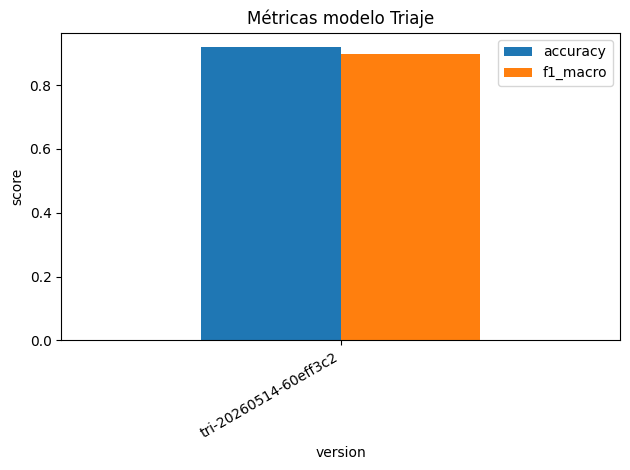

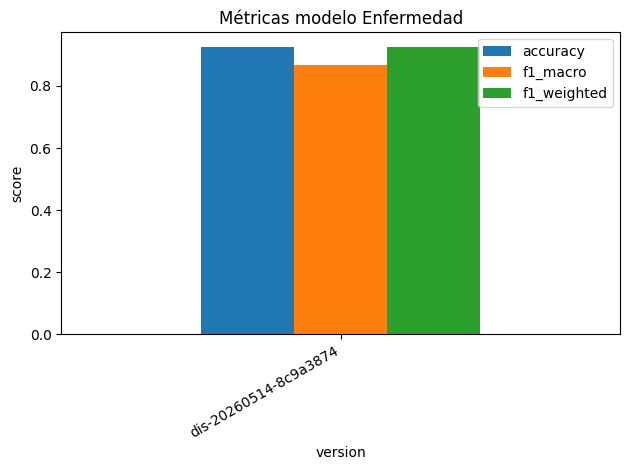

In [7]:
for name, df in [("Triaje", triage_metrics), ("Enfermedad", disease_metrics)]:
    if not df.empty and "accuracy" in df:
        plot_df = df.set_index("version")[[c for c in ["accuracy", "f1_macro", "f1_weighted"] if c in df.columns]].dropna(axis=1, how="all")
        if not plot_df.empty:
            ax = plot_df.plot(kind="bar")
            ax.set_title(f"Métricas modelo {name}")
            ax.set_ylabel("score")
            plt.xticks(rotation=30, ha="right")
            plt.tight_layout()
            plt.show()


## 4. Matrices de confusión

Las matrices de confusión se guardan como imágenes PNG dentro de cada artefacto.

models\triage\tri-20260514-60eff3c2\confusion_matrix.png


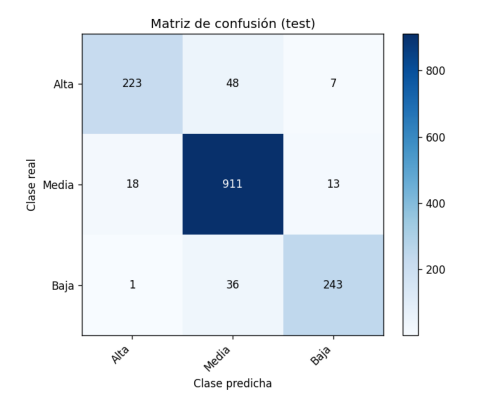

models\disease\dis-20260514-8c9a3874\confusion_matrix.png


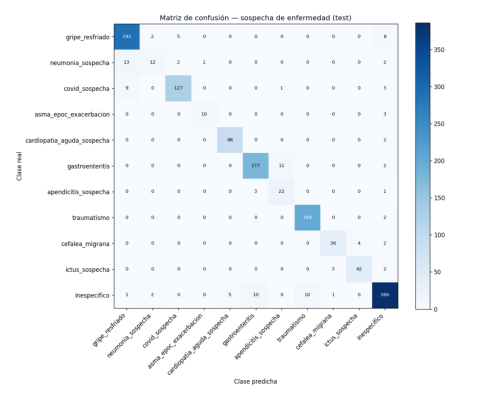

In [8]:
from PIL import Image

for root in [ROOT/"models/triage", ROOT/"models/disease"]:
    if not root.exists():
        continue
    for png in sorted(root.glob("*/confusion_matrix.png")):
        print(png.relative_to(ROOT))
        img = Image.open(png)
        plt.figure(figsize=(6, 5))
        plt.imshow(img)
        plt.axis("off")
        plt.show()


## 5. Interpretación clínica

Para triaje, el error más peligroso no es simétrico:

- `Alta → Baja`: riesgo alto, demora asistencial.
- `Alta → Media`: riesgo medio, prioridad menor de la necesaria.
- `Baja → Alta`: menor riesgo clínico, pero sobrecarga recursos.

Para sospecha de enfermedad:

- COVID o neumonía no detectada implica riesgo clínico/epidemiológico.
- Falsos positivos generan pruebas y ansiedad, pero suelen ser menos graves que falsos negativos críticos.

## 6. Comandos de reproducción

Entrenar modelos tabulares:

```powershell
.\scripts\train_tabular_models.ps1
```

Evaluar modelos tabulares:

```powershell
.\scripts\evaluate_tabular_models.ps1
```

Healthcheck:

```powershell
docker compose exec ml-triage curl -s http://localhost:8002/health
```